# Analyse des Erreurs - NLI4CT

Ce notebook permet d'analyser les erreurs des modèles en comparant les prédictions avec les métadonnées du dataset original.

## 1. Configuration et chargement des données

In [56]:
import json
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Configuration des chemins (racine = parent de code/ si lancé depuis code/)
_CWD = Path(".").resolve()
PROJECT_ROOT = _CWD if (_CWD / "reports").exists() else _CWD.parent
DATA_DIR = PROJECT_ROOT / "code" / "data" if (PROJECT_ROOT / "code" / "data").exists() else PROJECT_ROOT / "data"
CSV_BASELINE = PROJECT_ROOT / "reports" / "predictions_bl_NLI4CT.csv"
CSV_FINETUNED = PROJECT_ROOT / "reports" / "predictions_ft_NLI4CT.csv"
GOLD_TEST_JSONL = DATA_DIR / "Gold_test_formatted.jsonl"

# Style pour les graphiques
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

In [57]:
# Charger les CSV de prédictions
print("Chargement des CSV...")
df_baseline = pd.read_csv(CSV_BASELINE)
df_finetuned = pd.read_csv(CSV_FINETUNED)

print(f"Baseline: {len(df_baseline)} exemples")
print(f"Finetuné: {len(df_finetuned)} exemples")

# Convertir is_correct en booléen si c'est une string
if df_baseline['is_correct'].dtype == 'object':
    df_baseline['is_correct'] = df_baseline['is_correct'].apply(lambda x: str(x) == 'True' or x == True)
if df_finetuned['is_correct'].dtype == 'object':
    df_finetuned['is_correct'] = df_finetuned['is_correct'].apply(lambda x: str(x) == 'True' or x == True)

df_baseline.head()

Chargement des CSV...
Baseline: 500 exemples
Finetuné: 500 exemples


,index,premise,hypothesis,true_label,predicted_label,is_correct,raw_generated
0,0,Contradiction,NaN,Contradiction,Contradiction,True,Contradiction
1,1,Entailment,NaN,Entailment,Contradiction,False,Contradiction
2,2,Entailment,NaN,Entailment,Contradiction,False,Contradiction
3,3,Entailment,NaN,Entailment,Entailment,True,Entailment
4,4,Contradiction,NaN,Contradiction,Contradiction,True,Contradiction


In [58]:
# Charger Gold_test_formatted.jsonl (format messages user/assistant)
def extract_hypothesis_from_user_content(text):
    """Extrait l'hypothesis (statement) du contenu user (après HYPOTHESIS: et avant ? Answer)."""
    if "HYPOTHESIS:" not in text:
        return text[:200] if len(text) > 200 else text
    part = text.split("HYPOTHESIS:", 1)[1]
    for sep in (".? Answer", "? Answer", "?"):
        if sep in part:
            part = part.split(sep)[0]
    return part.strip()

print("Chargement de Gold_test_formatted.jsonl...")
metadata_list = []
with open(GOLD_TEST_JSONL, 'r', encoding='utf-8') as f:
    for idx, line in enumerate(f):
        if not line.strip():
            continue
        obj = json.loads(line)
        msgs = obj.get("messages", [])
        if len(msgs) < 2:
            continue
        user_content = msgs[0].get("content", "")
        label = msgs[1].get("content", "").strip()
        statement = extract_hypothesis_from_user_content(user_content)
        metadata_list.append({
            'index': idx,
            'type': 'N/A',
            'section_id': 'N/A',
            'statement': statement,
            'label': label
        })

# Remplir type (Single/Comparison) et section_id depuis Gold_test.json si disponible et même ordre
gold_test_json = DATA_DIR / "Gold_test.json"
if gold_test_json.exists():
    with open(gold_test_json, 'r', encoding='utf-8') as f:
        gold_test_data = json.load(f)
    gold_keys = list(gold_test_data.keys())
    if len(gold_keys) == len(metadata_list):
        for idx in range(len(metadata_list)):
            entry = gold_test_data[gold_keys[idx]]
            metadata_list[idx]['type'] = entry.get('Type', 'N/A')
            metadata_list[idx]['section_id'] = entry.get('Section_id', 'N/A')
        print(f"Type et Section_id remplis depuis Gold_test.json ({len(gold_keys)} entrées).")
    else:
        print(f"Gold_test.json a {len(gold_keys)} entrées, JSONL a {len(metadata_list)} — ordre non aligné, type/section_id restent N/A.")

df_metadata = pd.DataFrame(metadata_list)
print(f"Métadonnées chargées: {len(df_metadata)} exemples")
df_metadata.head()

Chargement de Gold_test_formatted.jsonl...
Type et Section_id remplis depuis Gold_test.json (500 entrées).
Métadonnées chargées: 500 exemples


,index,type,section_id,statement,label
0,0,Comparison,Eligibility,Women suffering from both claustrophobia and I...,Contradiction
1,1,Single,Eligibility,There are no conditions on mental mental healt...,Entailment
2,2,Comparison,Eligibility,the secondary trial requires patients to be ov...,Entailment
3,3,Comparison,Eligibility,Patients currently taking part in the secondar...,Entailment
4,4,Comparison,Intervention,HER2 + Patients in the primary trial receive t...,Contradiction


In [59]:
# Fusionner les données de prédictions avec les métadonnées
df_baseline_merged = df_baseline.merge(df_metadata, on='index', how='left')
df_finetuned_merged = df_finetuned.merge(df_metadata, on='index', how='left')

# Si hypothesis (ou premise) est NaN (CSV généré avant correctif evaluate.py), remplir depuis les métadonnées
if 'hypothesis' in df_baseline_merged.columns and 'statement' in df_baseline_merged.columns:
    df_baseline_merged['hypothesis'] = df_baseline_merged['hypothesis'].fillna(df_baseline_merged['statement'])
    df_finetuned_merged['hypothesis'] = df_finetuned_merged['hypothesis'].fillna(df_finetuned_merged['statement'])

print(f"Baseline merged: {len(df_baseline_merged)} exemples")
print(f"Finetuné merged: {len(df_finetuned_merged)} exemples")

# Vérifier qu'il n'y a pas de valeurs manquantes
print(f"\nValeurs manquantes dans baseline:")
print(df_baseline_merged[['type', 'section_id']].isnull().sum())
print(f"\nValeurs manquantes dans finetuné:")
print(df_finetuned_merged[['type', 'section_id']].isnull().sum())

Baseline merged: 500 exemples
Finetuné merged: 500 exemples

Valeurs manquantes dans baseline:
type          0
section_id    0
dtype: int64

Valeurs manquantes dans finetuné:
type          0
section_id    0
dtype: int64


## 2. Statistiques globales

In [60]:
# Calculer les accuracy globales
acc_baseline = df_baseline_merged['is_correct'].mean()
acc_finetuned = df_finetuned_merged['is_correct'].mean()

print("="*60)
print("ACCURACY GLOBALE")
print("="*60)
print(f"Baseline:  {acc_baseline:.4f} ({acc_baseline*100:.2f}%)")
print(f"Finetuné:  {acc_finetuned:.4f} ({acc_finetuned*100:.2f}%)")
print(f"Amélioration: {acc_finetuned - acc_baseline:+.4f} ({(acc_finetuned - acc_baseline)*100:+.2f}%)")
print("="*60)

ACCURACY GLOBALE
Baseline:  0.6640 (66.40%)
Finetuné:  0.7420 (74.20%)
Amélioration: +0.0780 (+7.80%)


## 3. Analyse par Type (Single vs Comparison)

In [61]:
# Analyse par Type pour Baseline
baseline_by_type = df_baseline_merged.groupby('type').agg({
    'is_correct': ['count', 'sum', 'mean']
}).round(4)
baseline_by_type.columns = ['total', 'correct', 'accuracy']
baseline_by_type['errors'] = baseline_by_type['total'] - baseline_by_type['correct']
baseline_by_type['error_rate'] = 1 - baseline_by_type['accuracy']

# Analyse par Type pour Finetuné
finetuned_by_type = df_finetuned_merged.groupby('type').agg({
    'is_correct': ['count', 'sum', 'mean']
}).round(4)
finetuned_by_type.columns = ['total', 'correct', 'accuracy']
finetuned_by_type['errors'] = finetuned_by_type['total'] - finetuned_by_type['correct']
finetuned_by_type['error_rate'] = 1 - finetuned_by_type['accuracy']

print("="*60)
print("ANALYSE PAR TYPE")
print("="*60)
print("\n--- BASELINE ---")
print(baseline_by_type)
print("\n--- FINETUNÉ ---")
print(finetuned_by_type)

# Comparaison
comparison_type = pd.DataFrame({
    'baseline_acc': baseline_by_type['accuracy'],
    'finetuned_acc': finetuned_by_type['accuracy'],
    'improvement': finetuned_by_type['accuracy'] - baseline_by_type['accuracy']
})
print("\n--- COMPARAISON ---")
print(comparison_type)

ANALYSE PAR TYPE

--- BASELINE ---
            total  correct  accuracy  errors  error_rate
type                                                    
Comparison    271      172    0.6347      99      0.3653
Single        229      160    0.6987      69      0.3013

--- FINETUNÉ ---
            total  correct  accuracy  errors  error_rate
type                                                    
Comparison    271      195    0.7196      76      0.2804
Single        229      176    0.7686      53      0.2314

--- COMPARAISON ---
            baseline_acc  finetuned_acc  improvement
type                                                
Comparison        0.6347         0.7196       0.0849
Single            0.6987         0.7686       0.0699


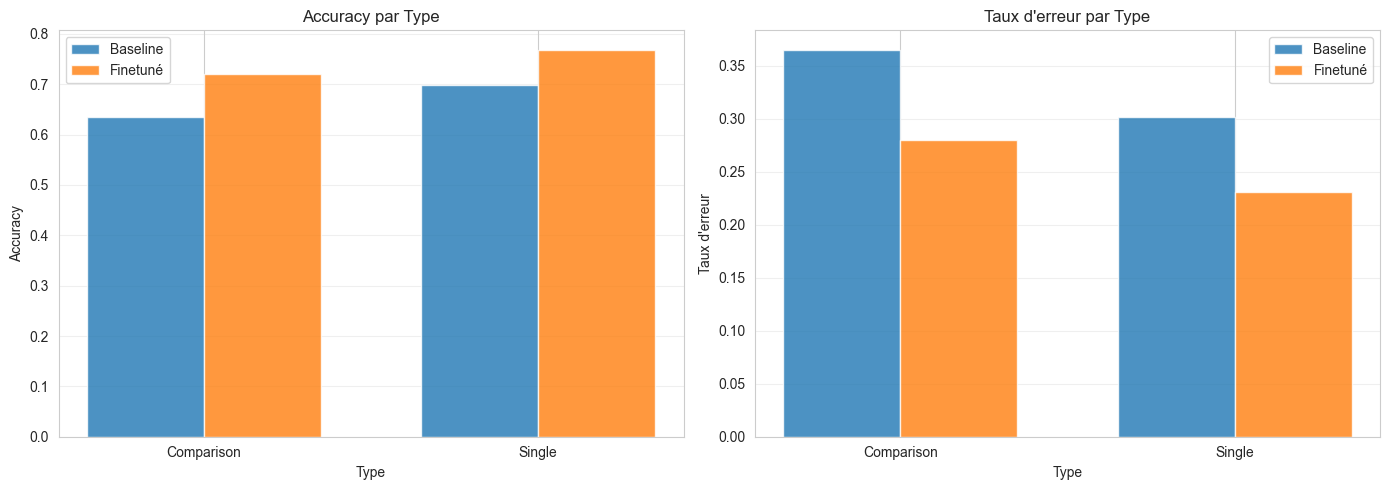

In [62]:
# Visualisation par Type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1: Accuracy par Type
types = baseline_by_type.index
x = np.arange(len(types))
width = 0.35

axes[0].bar(x - width/2, baseline_by_type['accuracy'], width, label='Baseline', alpha=0.8)
axes[0].bar(x + width/2, finetuned_by_type['accuracy'], width, label='Finetuné', alpha=0.8)
axes[0].set_xlabel('Type')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy par Type')
axes[0].set_xticks(x)
axes[0].set_xticklabels(types)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Graphique 2: Taux d'erreur par Type
axes[1].bar(x - width/2, baseline_by_type['error_rate'], width, label='Baseline', alpha=0.8)
axes[1].bar(x + width/2, finetuned_by_type['error_rate'], width, label='Finetuné', alpha=0.8)
axes[1].set_xlabel('Type')
axes[1].set_ylabel('Taux d\'erreur')
axes[1].set_title('Taux d\'erreur par Type')
axes[1].set_xticks(x)
axes[1].set_xticklabels(types)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Analyse par Section_id

In [63]:
# Analyse par Section_id pour Baseline
baseline_by_section = df_baseline_merged.groupby('section_id').agg({
    'is_correct': ['count', 'sum', 'mean']
}).round(4)
baseline_by_section.columns = ['total', 'correct', 'accuracy']
baseline_by_section['errors'] = baseline_by_section['total'] - baseline_by_section['correct']
baseline_by_section['error_rate'] = 1 - baseline_by_section['accuracy']
baseline_by_section = baseline_by_section.sort_values('error_rate', ascending=False)

# Analyse par Section_id pour Finetuné
finetuned_by_section = df_finetuned_merged.groupby('section_id').agg({
    'is_correct': ['count', 'sum', 'mean']
}).round(4)
finetuned_by_section.columns = ['total', 'correct', 'accuracy']
finetuned_by_section['errors'] = finetuned_by_section['total'] - finetuned_by_section['correct']
finetuned_by_section['error_rate'] = 1 - finetuned_by_section['accuracy']
finetuned_by_section = finetuned_by_section.sort_values('error_rate', ascending=False)

print("="*60)
print("ANALYSE PAR SECTION_ID")
print("="*60)
print("\n--- BASELINE (trié par taux d'erreur décroissant) ---")
print(baseline_by_section)
print("\n--- FINETUNÉ (trié par taux d'erreur décroissant) ---")
print(finetuned_by_section)

# Comparaison
comparison_section = pd.DataFrame({
    'baseline_acc': baseline_by_section['accuracy'],
    'finetuned_acc': finetuned_by_section['accuracy'],
    'improvement': finetuned_by_section['accuracy'] - baseline_by_section['accuracy']
})
print("\n--- COMPARAISON ---")
print(comparison_section.sort_values('improvement', ascending=False))

ANALYSE PAR SECTION_ID

--- BASELINE (trié par taux d'erreur décroissant) ---
                total  correct  accuracy  errors  error_rate
section_id                                                  
Eligibility       132       80    0.6061      52      0.3939
Intervention      142       95    0.6690      47      0.3310
Adverse Events    120       83    0.6917      37      0.3083
Results           106       74    0.6981      32      0.3019

--- FINETUNÉ (trié par taux d'erreur décroissant) ---
                total  correct  accuracy  errors  error_rate
section_id                                                  
Eligibility       132       95    0.7197      37      0.2803
Results           106       77    0.7264      29      0.2736
Intervention      142      105    0.7394      37      0.2606
Adverse Events    120       94    0.7833      26      0.2167

--- COMPARAISON ---
                baseline_acc  finetuned_acc  improvement
section_id                                              


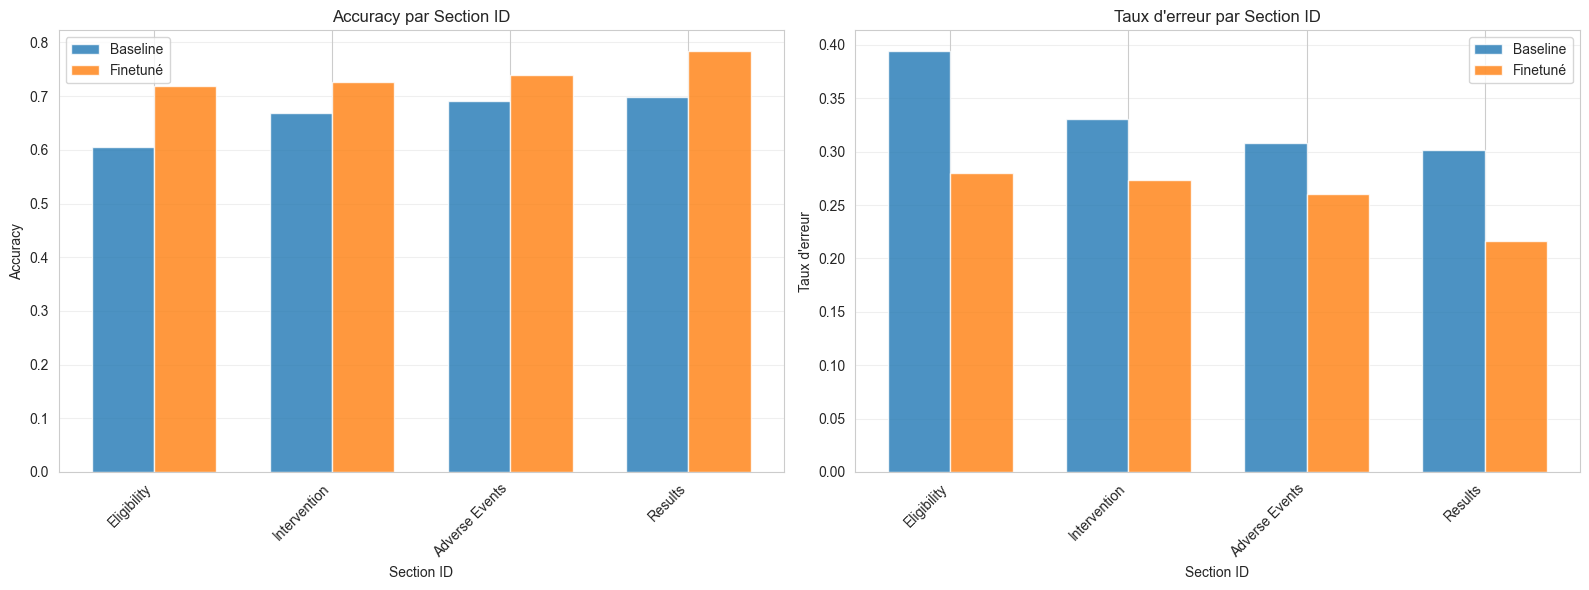

In [64]:
# Visualisation par Section_id
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sections = baseline_by_section.index
x = np.arange(len(sections))
width = 0.35

# Graphique 1: Accuracy par Section
axes[0].bar(x - width/2, baseline_by_section['accuracy'], width, label='Baseline', alpha=0.8)
axes[0].bar(x + width/2, finetuned_by_section['accuracy'], width, label='Finetuné', alpha=0.8)
axes[0].set_xlabel('Section ID')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy par Section ID')
axes[0].set_xticks(x)
axes[0].set_xticklabels(sections, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Graphique 2: Taux d'erreur par Section
axes[1].bar(x - width/2, baseline_by_section['error_rate'], width, label='Baseline', alpha=0.8)
axes[1].bar(x + width/2, finetuned_by_section['error_rate'], width, label='Finetuné', alpha=0.8)
axes[1].set_xlabel('Section ID')
axes[1].set_ylabel('Taux d\'erreur')
axes[1].set_title('Taux d\'erreur par Section ID')
axes[1].set_xticks(x)
axes[1].set_xticklabels(sections, rotation=45, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Analyse croisée Type × Section_id

In [65]:
# Analyse croisée pour Baseline
baseline_cross = df_baseline_merged.groupby(['type', 'section_id']).agg({
    'is_correct': ['count', 'sum', 'mean']
}).round(4)
baseline_cross.columns = ['total', 'correct', 'accuracy']
baseline_cross['error_rate'] = 1 - baseline_cross['accuracy']

# Analyse croisée pour Finetuné
finetuned_cross = df_finetuned_merged.groupby(['type', 'section_id']).agg({
    'is_correct': ['count', 'sum', 'mean']
}).round(4)
finetuned_cross.columns = ['total', 'correct', 'accuracy']
finetuned_cross['error_rate'] = 1 - finetuned_cross['accuracy']

print("="*60)
print("ANALYSE CROISÉE TYPE × SECTION_ID")
print("="*60)
print("\n--- BASELINE (trié par taux d'erreur décroissant) ---")
print(baseline_cross.sort_values('error_rate', ascending=False))
print("\n--- FINETUNÉ (trié par taux d'erreur décroissant) ---")
print(finetuned_cross.sort_values('error_rate', ascending=False))

ANALYSE CROISÉE TYPE × SECTION_ID

--- BASELINE (trié par taux d'erreur décroissant) ---
                           total  correct  accuracy  error_rate
type       section_id                                          
Comparison Eligibility        88       51    0.5795      0.4205
           Results            43       28    0.6512      0.3488
Single     Eligibility        44       29    0.6591      0.3409
Comparison Intervention       68       45    0.6618      0.3382
           Adverse Events     72       48    0.6667      0.3333
Single     Intervention       74       50    0.6757      0.3243
           Adverse Events     48       35    0.7292      0.2708
           Results            63       46    0.7302      0.2698

--- FINETUNÉ (trié par taux d'erreur décroissant) ---
                           total  correct  accuracy  error_rate
type       section_id                                          
Comparison Eligibility        88       59    0.6705      0.3295
           Intervention 

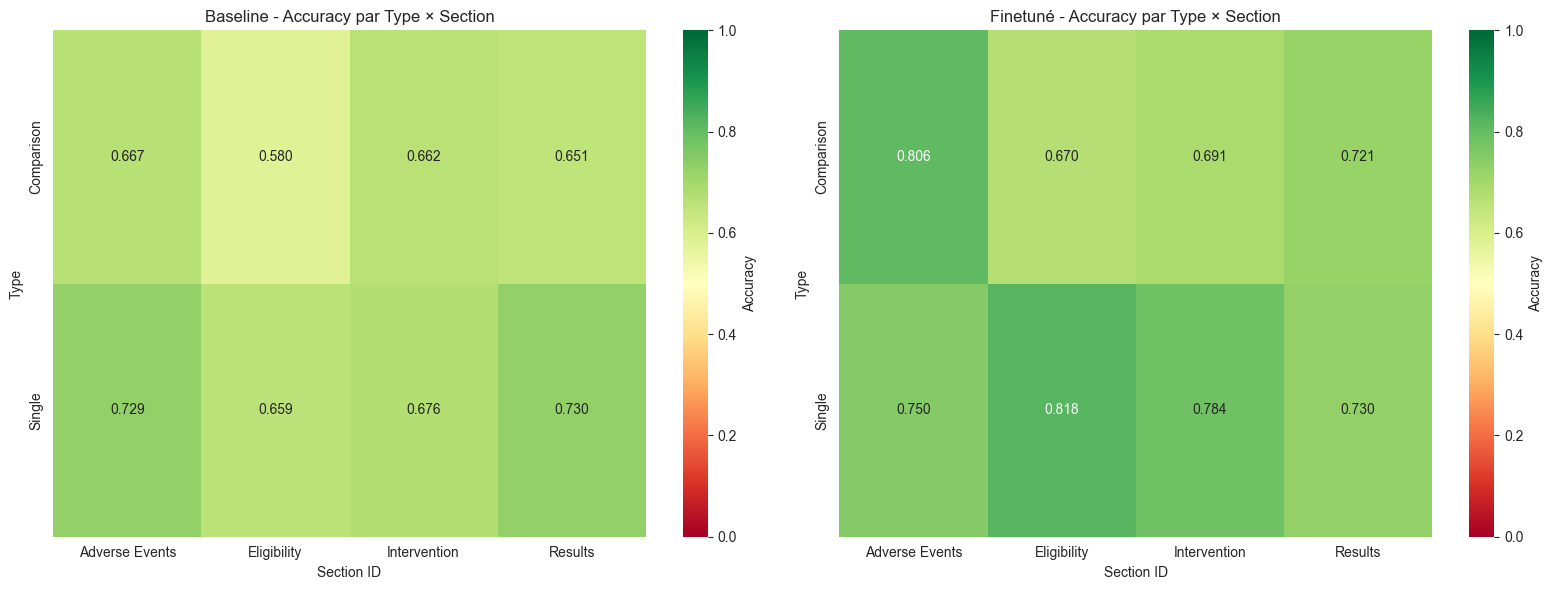

In [66]:
# Heatmap de l'accuracy par Type × Section_id
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Baseline
baseline_pivot = baseline_cross['accuracy'].unstack(fill_value=0)
sns.heatmap(baseline_pivot, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=1, ax=axes[0], cbar_kws={'label': 'Accuracy'})
axes[0].set_title('Baseline - Accuracy par Type × Section')
axes[0].set_xlabel('Section ID')
axes[0].set_ylabel('Type')

# Finetuné
finetuned_pivot = finetuned_cross['accuracy'].unstack(fill_value=0)
sns.heatmap(finetuned_pivot, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=1, ax=axes[1], cbar_kws={'label': 'Accuracy'})
axes[1].set_title('Finetuné - Accuracy par Type × Section')
axes[1].set_xlabel('Section ID')
axes[1].set_ylabel('Type')

plt.tight_layout()
plt.show()

## 6. Analyse des erreurs spécifiques

In [67]:
# Identifier les exemples où les deux modèles se trompent
both_wrong = df_baseline_merged[
    (~df_baseline_merged['is_correct']) & (~df_finetuned_merged['is_correct'])
].copy()

# Identifier les exemples où seul le baseline se trompe (finetuné corrige)
baseline_wrong_finetuned_correct = df_baseline_merged[
    (~df_baseline_merged['is_correct']) & (df_finetuned_merged['is_correct'])
].copy()

# Identifier les exemples où seul le finetuné se trompe (régression)
baseline_correct_finetuned_wrong = df_baseline_merged[
    (df_baseline_merged['is_correct']) & (~df_finetuned_merged['is_correct'])
].copy()

print("="*60)
print("ANALYSE DES ERREURS")
print("="*60)
print(f"\nLes deux modèles se trompent: {len(both_wrong)} exemples")
print(f"Baseline se trompe, Finetuné corrige: {len(baseline_wrong_finetuned_correct)} exemples")
print(f"Baseline correct, Finetuné se trompe (régression): {len(baseline_correct_finetuned_wrong)} exemples")

# Analyser les erreurs communes par Type et Section
if len(both_wrong) > 0:
    print("\n--- Erreurs communes par Type ---")
    print(both_wrong['type'].value_counts())
    print("\n--- Erreurs communes par Section ---")
    print(both_wrong['section_id'].value_counts())

ANALYSE DES ERREURS

Les deux modèles se trompent: 65 exemples
Baseline se trompe, Finetuné corrige: 103 exemples
Baseline correct, Finetuné se trompe (régression): 64 exemples

--- Erreurs communes par Type ---
type
Comparison    41
Single        24
Name: count, dtype: int64

--- Erreurs communes par Section ---
section_id
Eligibility       26
Intervention      16
Results           13
Adverse Events    10
Name: count, dtype: int64


## 6.1. Analyse détaillée des RÉGRESSIONS (Baseline correct → Finetuné incorrect)

⚠️ **Attention** : Ces exemples sont critiques car le finetuning a dégradé les performances par rapport à la baseline.

In [68]:
# Analyse statistique des régressions
if len(baseline_correct_finetuned_wrong) > 0:
    print("="*60)
    print("ANALYSE DES RÉGRESSIONS")
    print("="*60)
    print(f"\nNombre total de régressions: {len(baseline_correct_finetuned_wrong)}")
    print(f"Taux de régression: {len(baseline_correct_finetuned_wrong)/len(df_baseline_merged)*100:.2f}%")
    
    # Analyse par Type
    print("\n--- Régressions par Type ---")
    regressions_by_type = baseline_correct_finetuned_wrong['type'].value_counts()
    total_by_type = df_baseline_merged['type'].value_counts()
    regression_rate_by_type = (regressions_by_type / total_by_type * 100).round(2)
    print(regressions_by_type)
    print("\nTaux de régression par Type (%):")
    print(regression_rate_by_type)
    
    # Analyse par Section
    print("\n--- Régressions par Section ---")
    regressions_by_section = baseline_correct_finetuned_wrong['section_id'].value_counts()
    total_by_section = df_baseline_merged['section_id'].value_counts()
    regression_rate_by_section = (regressions_by_section / total_by_section * 100).round(2)
    print(regressions_by_section)
    print("\nTaux de régression par Section (%):")
    print(regression_rate_by_section)
    
    # Analyse croisée Type × Section
    print("\n--- Régressions par Type × Section ---")
    regressions_cross = baseline_correct_finetuned_wrong.groupby(['type', 'section_id']).size()
    print(regressions_cross.sort_values(ascending=False))
else:
    print("✅ Aucune régression détectée ! Le finetuning n'a pas dégradé de cas où la baseline était correcte.")

ANALYSE DES RÉGRESSIONS

Nombre total de régressions: 64
Taux de régression: 12.80%

--- Régressions par Type ---
type
Comparison    35
Single        29
Name: count, dtype: int64

Taux de régression par Type (%):
type
Comparison    12.92
Single        12.66
Name: count, dtype: float64

--- Régressions par Section ---
section_id
Intervention      21
Adverse Events    16
Results           16
Eligibility       11
Name: count, dtype: int64

Taux de régression par Section (%):
section_id
Adverse Events    13.33
Eligibility        8.33
Intervention      14.79
Results           15.09
Name: count, dtype: float64

--- Régressions par Type × Section ---
type        section_id    
Comparison  Intervention      11
            Eligibility       10
Single      Intervention      10
            Adverse Events     9
            Results            9
Comparison  Adverse Events     7
            Results            7
Single      Eligibility        1
dtype: int64


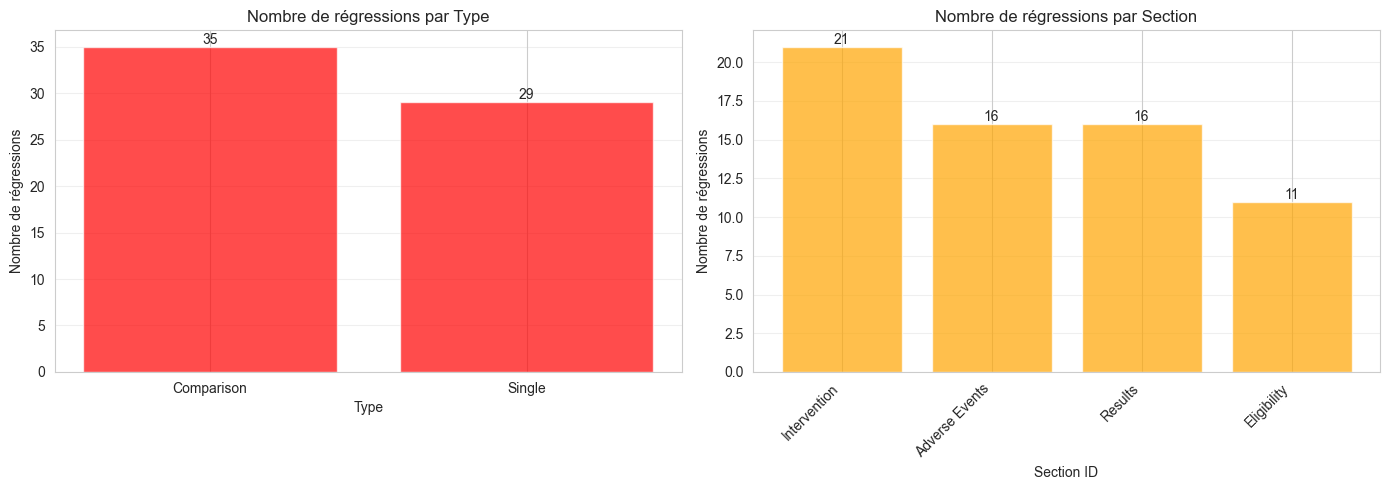

In [69]:
# Visualisation des régressions
if len(baseline_correct_finetuned_wrong) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Graphique 1: Régressions par Type
    regressions_by_type = baseline_correct_finetuned_wrong['type'].value_counts()
    axes[0].bar(regressions_by_type.index, regressions_by_type.values, color='red', alpha=0.7)
    axes[0].set_xlabel('Type')
    axes[0].set_ylabel('Nombre de régressions')
    axes[0].set_title('Nombre de régressions par Type')
    axes[0].grid(axis='y', alpha=0.3)
    for i, v in enumerate(regressions_by_type.values):
        axes[0].text(i, v, str(v), ha='center', va='bottom')
    
    # Graphique 2: Régressions par Section
    regressions_by_section = baseline_correct_finetuned_wrong['section_id'].value_counts()
    axes[1].bar(range(len(regressions_by_section)), regressions_by_section.values, color='orange', alpha=0.7)
    axes[1].set_xlabel('Section ID')
    axes[1].set_ylabel('Nombre de régressions')
    axes[1].set_title('Nombre de régressions par Section')
    axes[1].set_xticks(range(len(regressions_by_section)))
    axes[1].set_xticklabels(regressions_by_section.index, rotation=45, ha='right')
    axes[1].grid(axis='y', alpha=0.3)
    for i, v in enumerate(regressions_by_section.values):
        axes[1].text(i, v, str(v), ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()

In [70]:
# Fonction helper pour décrire les sections (doit être définie avant utilisation)
def get_section_description(section_id):
    """Retourne une description de la section"""
    descriptions = {
        "Eligibility": "Critères d'éligibilité (inclusion/exclusion)",
        "Intervention": "Traitements et interventions testés",
        "Adverse Events": "Effets secondaires et événements indésirables",
        "Results": "Résultats de l'essai (efficacité, taux de réponse, etc.)"
    }
    return descriptions.get(section_id, "Section inconnue")

In [71]:
# Afficher des exemples détaillés de régressions
if len(baseline_correct_finetuned_wrong) > 0:
    print("="*60)
    print("EXEMPLES DÉTAILLÉS DE RÉGRESSIONS")
    print("="*60)
    print("\n⚠️ Ces exemples montrent où le finetuning a introduit des erreurs.")
    print("Analysez-les pour comprendre ce qui a mal tourné.\n")
    
    # Trier par Type et Section pour voir les patterns
    regressions_sorted = baseline_correct_finetuned_wrong.sort_values(['type', 'section_id'])
    
    for idx, row in regressions_sorted.head(10).iterrows():
        print(f"\n{'='*80}")
        print(f"Exemple {row['index']} - Type: {row['type']}, Section: {row['section_id']}")
        print(f"{'='*80}")
        print(f"\n📋 Statement (hypothesis):")
        print(f"   {row['statement'][:300]}...")
        print(f"\n✅ True Label: {row['true_label']}")
        print(f"✅ Baseline prédit correctement: {row['predicted_label']}")
        print(f"❌ Finetuné prédit incorrectement: {df_finetuned_merged.loc[idx, 'predicted_label']}")
        print(f"\n📝 Premise (extraits CT):")
        premise_short = row['premise'][:400] if len(row['premise']) > 400 else row['premise']
        print(f"   {premise_short}...")
        print(f"\n🤖 Baseline raw output:")
        print(f"   {row['raw_generated'][:200]}...")
        print(f"\n🤖 Finetuné raw output:")
        finetuned_raw = df_finetuned_merged.loc[idx, 'raw_generated']
        print(f"   {finetuned_raw[:200]}...")
        
        # Analyser pourquoi le finetuné s'est trompé
        print(f"\n🔍 Analyse:")
        if "entailment" in finetuned_raw.lower() and row['true_label'] == "Contradiction":
            print("   → Le finetuné a détecté 'entailment' alors que c'est 'contradiction'")
        elif "contradiction" in finetuned_raw.lower() and row['true_label'] == "Entailment":
            print("   → Le finetuné a détecté 'contradiction' alors que c'est 'entailment'")
        else:
            print("   → Le finetuné n'a pas généré un label clair (problème de format)")
        
        if row['type'] == 'Comparison':
            print(f"   → Type Comparison: nécessite de comparer deux essais cliniques")
        else:
            print(f"   → Type Single: concerne un seul essai clinique")
        
        print(f"   → Section {row['section_id']}: {get_section_description(row['section_id'])}")
        
        if idx >= regressions_sorted.head(10).index[-1]:
            break

EXEMPLES DÉTAILLÉS DE RÉGRESSIONS

⚠️ Ces exemples montrent où le finetuning a introduit des erreurs.
Analysez-les pour comprendre ce qui a mal tourné.


Exemple 19 - Type: Comparison, Section: Adverse Events

📋 Statement (hypothesis):
   Patients in the primary trial and the secondary trial  suffered Thromboembolic events...

✅ True Label: Contradiction
✅ Baseline prédit correctement: Contradiction
❌ Finetuné prédit incorrectement: Entailment

📝 Premise (extraits CT):
   Contradiction...

🤖 Baseline raw output:
   Contradiction...

🤖 Finetuné raw output:
   Entailment...

🔍 Analyse:
   → Le finetuné a détecté 'entailment' alors que c'est 'contradiction'
   → Type Comparison: nécessite de comparer deux essais cliniques
   → Section Adverse Events: Effets secondaires et événements indésirables

Exemple 48 - Type: Comparison, Section: Adverse Events

📋 Statement (hypothesis):
   The only types of Aes observed in patients from the secondary trial were Eyelid oedema, Upper gastrointestinal

In [72]:
# Fonction helper pour décrire les sections
def get_section_description(section_id):
    """Retourne une description de la section"""
    descriptions = {
        "Eligibility": "Critères d'éligibilité (inclusion/exclusion)",
        "Intervention": "Traitements et interventions testés",
        "Adverse Events": "Effets secondaires et événements indésirables",
        "Results": "Résultats de l'essai (efficacité, taux de réponse, etc.)"
    }
    return descriptions.get(section_id, "Section inconnue")

# Analyse des patterns dans les régressions
if len(baseline_correct_finetuned_wrong) > 0:
    print("="*60)
    print("PATTERNS DANS LES RÉGRESSIONS")
    print("="*60)
    
    # Vérifier si les régressions sont concentrées sur certains types de labels
    print("\n--- Distribution des labels vrais dans les régressions ---")
    true_labels_in_regressions = baseline_correct_finetuned_wrong['true_label'].value_counts()
    print(true_labels_in_regressions)
    print(f"\nProportion Entailment: {true_labels_in_regressions.get('Entailment', 0) / len(baseline_correct_finetuned_wrong) * 100:.1f}%")
    print(f"Proportion Contradiction: {true_labels_in_regressions.get('Contradiction', 0) / len(baseline_correct_finetuned_wrong) * 100:.1f}%")
    
    # Vérifier ce que le finetuné prédit à la place
    print("\n--- Ce que le finetuné prédit (incorrectement) ---")
    finetuned_wrong_predictions = baseline_correct_finetuned_wrong.apply(
        lambda row: df_finetuned_merged.loc[row.name, 'predicted_label'], axis=1
    ).value_counts()
    print(finetuned_wrong_predictions)
    
    # Matrice de confusion pour les régressions
    print("\n--- Matrice de confusion (régressions uniquement) ---")
    confusion_regressions = pd.crosstab(
        baseline_correct_finetuned_wrong['true_label'],
        baseline_correct_finetuned_wrong.apply(
            lambda row: df_finetuned_merged.loc[row.name, 'predicted_label'], axis=1
        ),
        margins=True
    )
    print(confusion_regressions)
    
    # Identifier les cas où le finetuné prédit "UNKNOWN"
    unknown_predictions = baseline_correct_finetuned_wrong[
        baseline_correct_finetuned_wrong.apply(
            lambda row: df_finetuned_merged.loc[row.name, 'predicted_label'] == 'UNKNOWN', axis=1
        )
    ]
    if len(unknown_predictions) > 0:
        print(f"\n⚠️ {len(unknown_predictions)} régressions où le finetuné n'a pas pu extraire un label clair (UNKNOWN)")
        print("   → Problème potentiel: le modèle génère du texte mais ne suit pas le format attendu")

PATTERNS DANS LES RÉGRESSIONS

--- Distribution des labels vrais dans les régressions ---
true_label
Contradiction    52
Entailment       12
Name: count, dtype: int64

Proportion Entailment: 18.8%
Proportion Contradiction: 81.2%

--- Ce que le finetuné prédit (incorrectement) ---
Entailment       52
Contradiction    12
Name: count, dtype: int64

--- Matrice de confusion (régressions uniquement) ---
col_0          Contradiction  Entailment  All
true_label                                   
Contradiction              0          52   52
Entailment                12           0   12
All                       12          52   64


### Interprétation des régressions

**Questions à se poser :**
1. **Y a-t-il un pattern ?** Les régressions sont-elles concentrées sur certains types (Single vs Comparison) ou sections ?
2. **Quel type d'erreur ?** Le finetuné prédit-il systématiquement l'inverse (Entailment → Contradiction) ou génère-t-il du texte non structuré ?
3. **Pourquoi la baseline était correcte ?** Le modèle de base avait-il une meilleure compréhension générale, ou le finetuning a-t-il introduit un biais ?
4. **Peut-on corriger ?** Ces régressions suggèrent-elles un besoin d'ajuster les hyperparamètres ou d'augmenter la diversité du dataset d'entraînement ?

## 7. Export des résultats détaillés

In [73]:
# Créer un DataFrame avec toutes les analyses
df_analysis = df_baseline_merged.copy()
df_analysis['baseline_correct'] = df_baseline_merged['is_correct']
df_analysis['finetuned_correct'] = df_finetuned_merged['is_correct']
df_analysis['baseline_pred'] = df_baseline_merged['predicted_label']
df_analysis['finetuned_pred'] = df_finetuned_merged['predicted_label']
# Convertir les booléens en int (0/1) pour pouvoir faire la soustraction
# improvement = 1 si finetuné correct et baseline incorrect (amélioration)
# improvement = -1 si finetuné incorrect et baseline correct (régression)
# improvement = 0 si les deux ont le même résultat
df_analysis['improvement'] = df_analysis['finetuned_correct'].astype(int) - df_analysis['baseline_correct'].astype(int)

# Sauvegarder
output_file = "error_analysis_detailed.csv"
df_analysis.to_csv(output_file, index=False)
print(f"Résultats détaillés sauvegardés dans: {output_file}")

Résultats détaillés sauvegardés dans: error_analysis_detailed.csv


## 8. Comparaison avec les résultats avant changement de prompt

On compare les résultats actuels (nouveau prompt + paramètres d'inférence) avec les anciens résultats (prompt et paramètres différents), stockés dans `reports/avant_changement_prompt/`. On analyse où les deux setups divergent (baseline vs baseline, finetuné vs finetuné) et les performances dans chaque cas.

In [74]:
# Chemins des résultats "avant changement de prompt"
DIR_AVANT = PROJECT_ROOT / "reports" / "avant_changement_prompt"
CSV_AVANT_BL = DIR_AVANT / "pred_bl_avant_chgt_prompt.csv"
CSV_AVANT_FT = DIR_AVANT / "pred_ft_avant_chgt_prompt.csv"

# Charger les anciens CSV (même format: index, predicted_label, is_correct, ...)
df_avant_bl = pd.read_csv(CSV_AVANT_BL)
df_avant_ft = pd.read_csv(CSV_AVANT_FT)
if df_avant_bl['is_correct'].dtype == 'object':
    df_avant_bl['is_correct'] = df_avant_bl['is_correct'].apply(lambda x: str(x) == 'True' or x == True)
if df_avant_ft['is_correct'].dtype == 'object':
    df_avant_ft['is_correct'] = df_avant_ft['is_correct'].apply(lambda x: str(x) == 'True' or x == True)

# Aligner sur les index communs (au cas où les anciens CSV auraient plus/moins de lignes)
common_idx = np.intersect1d(
    np.intersect1d(df_avant_bl['index'], df_avant_ft['index']),
    np.intersect1d(df_baseline_merged['index'], df_finetuned_merged['index'])
)
print(f"Exemples communs (ancien + actuel): {len(common_idx)}")
print(f"Ancien baseline: {len(df_avant_bl)} | Ancien finetuné: {len(df_avant_ft)}")

Exemples communs (ancien + actuel): 500
Ancien baseline: 500 | Ancien finetuné: 500


In [75]:
# Tableau de comparaison: un ligne par index avec ancien vs actuel (baseline et finetuné)
avant_bl = df_avant_bl.set_index('index').loc[common_idx]
avant_ft = df_avant_ft.set_index('index').loc[common_idx]
actu_bl = df_baseline_merged.set_index('index').loc[common_idx]
actu_ft = df_finetuned_merged.set_index('index').loc[common_idx]

df_compare = pd.DataFrame({
    'index': common_idx,
    'true_label': actu_bl['true_label'].values,
    'type': actu_bl['type'].values,
    'section_id': actu_bl['section_id'].values,
    'statement': actu_bl['statement'].values if 'statement' in actu_bl.columns else [''] * len(common_idx),
    # Ancien
    'avant_bl_pred': avant_bl['predicted_label'].values,
    'avant_ft_pred': avant_ft['predicted_label'].values,
    'avant_bl_correct': avant_bl['is_correct'].values,
    'avant_ft_correct': avant_ft['is_correct'].values,
    # Actuel
    'actu_bl_pred': actu_bl['predicted_label'].values,
    'actu_ft_pred': actu_ft['predicted_label'].values,
    'actu_bl_correct': actu_bl['is_correct'].values,
    'actu_ft_correct': actu_ft['is_correct'].values,
})

# Colonnes de divergence (les deux setups ne donnent pas la même prédiction)
df_compare['bl_divergent'] = df_compare['avant_bl_pred'] != df_compare['actu_bl_pred']
df_compare['ft_divergent'] = df_compare['avant_ft_pred'] != df_compare['actu_ft_pred']

print("Aperçu du tableau de comparaison:")
df_compare.head(10)

Aperçu du tableau de comparaison:


,index,true_label,type,section_id,statement,avant_bl_pred,avant_ft_pred,avant_bl_correct,avant_ft_correct,actu_bl_pred,actu_ft_pred,actu_bl_correct,actu_ft_correct,bl_divergent,ft_divergent
0,0,Contradiction,Comparison,Eligibility,Women suffering from both claustrophobia and I...,Contradiction,Contradiction,True,True,Contradiction,Contradiction,True,True,False,False
1,1,Entailment,Single,Eligibility,There are no conditions on mental mental healt...,Entailment,Contradiction,True,False,Contradiction,Entailment,False,True,True,True
2,2,Entailment,Comparison,Eligibility,the secondary trial requires patients to be ov...,Contradiction,Entailment,False,True,Contradiction,Entailment,False,True,False,False
3,3,Entailment,Comparison,Eligibility,Patients currently taking part in the secondar...,Entailment,Entailment,True,True,Entailment,Entailment,True,True,False,False
4,4,Contradiction,Comparison,Intervention,HER2 + Patients in the primary trial receive t...,Contradiction,Contradiction,True,True,Contradiction,Contradiction,True,True,False,False
5,5,Entailment,Comparison,Adverse Events,"There are no cases of anorexia, hypothermia or...",Entailment,Entailment,True,True,Contradiction,Entailment,False,True,True,False
6,6,Contradiction,Comparison,Eligibility,a patient that has received an organ transplan...,Contradiction,Entailment,True,False,Contradiction,Contradiction,True,True,False,True
7,7,Contradiction,Comparison,Eligibility,Any patients with Documented allergy to cephal...,Contradiction,Entailment,True,False,Contradiction,Contradiction,True,True,False,True
8,8,Entailment,Single,Intervention,The Interventions in the primary trial are adm...,Entailment,Entailment,True,True,Entailment,Entailment,True,True,False,False
9,9,Contradiction,Comparison,Eligibility,Women with Newly diagnosed stage IV breast can...,Contradiction,Contradiction,True,True,Contradiction,Contradiction,True,True,False,False


In [76]:
# Accuracy globale: ancien vs actuel
acc_avant_bl = df_compare['avant_bl_correct'].mean()
acc_avant_ft = df_compare['avant_ft_correct'].mean()
acc_actu_bl = df_compare['actu_bl_correct'].mean()
acc_actu_ft = df_compare['actu_ft_correct'].mean()

print("="*60)
print("ACCURACY GLOBALE — Ancien vs Actuel (même exemples)")
print("="*60)
print(f"Baseline   ancien: {acc_avant_bl:.4f} ({acc_avant_bl*100:.2f}%)  |  actuel: {acc_actu_bl:.4f} ({acc_actu_bl*100:.2f}%)  |  Δ = {acc_actu_bl - acc_avant_bl:+.4f}")
print(f"Finetuné   ancien: {acc_avant_ft:.4f} ({acc_avant_ft*100:.2f}%)  |  actuel: {acc_actu_ft:.4f} ({acc_actu_ft*100:.2f}%)  |  Δ = {acc_actu_ft - acc_avant_ft:+.4f}")
print("="*60)

# Nombre de cas où les deux setups divergent
n_bl_div = df_compare['bl_divergent'].sum()
n_ft_div = df_compare['ft_divergent'].sum()
print(f"\nDivergences (prédiction différente entre ancien et actuel):")
print(f"  Baseline:   {n_bl_div} / {len(df_compare)} ({100*n_bl_div/len(df_compare):.1f}%)")
print(f"  Finetuné:   {n_ft_div} / {len(df_compare)} ({100*n_ft_div/len(df_compare):.1f}%)")

ACCURACY GLOBALE — Ancien vs Actuel (même exemples)
Baseline   ancien: 0.6580 (65.80%)  |  actuel: 0.6640 (66.40%)  |  Δ = +0.0060
Finetuné   ancien: 0.7420 (74.20%)  |  actuel: 0.7420 (74.20%)  |  Δ = +0.0000

Divergences (prédiction différente entre ancien et actuel):
  Baseline:   77 / 500 (15.4%)
  Finetuné:   76 / 500 (15.2%)


In [77]:
# Performance selon accord / divergence entre ancien et actuel
# Baseline: quand les deux setups donnent la même prédiction -> un seul bon/mauvais; quand ils divergent -> comparer qui a raison
mask_bl_agree = ~df_compare['bl_divergent']
mask_ft_agree = ~df_compare['ft_divergent']

print("--- BASELINE (ancien vs actuel) ---")
print(f"Cas où les deux setups sont d'accord: {mask_bl_agree.sum()}. Dans ces cas, accuracy = {df_compare.loc[mask_bl_agree, 'actu_bl_correct'].mean():.4f} (identique ancien/actuel).")
print(f"Cas où les deux setups divergent: {df_compare['bl_divergent'].sum()}. Parmi eux:")
sub = df_compare[df_compare['bl_divergent']]
avant_ok = sub['avant_bl_correct'].sum()
actu_ok = sub['actu_bl_correct'].sum()
print(f"  Ancien correct: {avant_ok}  |  Actuel correct: {actu_ok}  (donc actuel gagne sur {actu_ok - avant_ok} exemples dans les divergences)")

print("\n--- FINETUNÉ (ancien vs actuel) ---")
print(f"Cas où les deux setups sont d'accord: {mask_ft_agree.sum()}. Dans ces cas, accuracy = {df_compare.loc[mask_ft_agree, 'actu_ft_correct'].mean():.4f}.")
print(f"Cas où les deux setups divergent: {df_compare['ft_divergent'].sum()}. Parmi eux:")
sub_ft = df_compare[df_compare['ft_divergent']]
print(f"  Ancien correct: {sub_ft['avant_ft_correct'].sum()}  |  Actuel correct: {sub_ft['actu_ft_correct'].sum()}  (actuel gagne sur {sub_ft['actu_ft_correct'].sum() - sub_ft['avant_ft_correct'].sum()} exemples)")

--- BASELINE (ancien vs actuel) ---
Cas où les deux setups sont d'accord: 423. Dans ces cas, accuracy = 0.6903 (identique ancien/actuel).
Cas où les deux setups divergent: 77. Parmi eux:
  Ancien correct: 37  |  Actuel correct: 40  (donc actuel gagne sur 3 exemples dans les divergences)

--- FINETUNÉ (ancien vs actuel) ---
Cas où les deux setups sont d'accord: 424. Dans ces cas, accuracy = 0.7854.
Cas où les deux setups divergent: 76. Parmi eux:
  Ancien correct: 38  |  Actuel correct: 38  (actuel gagne sur 0 exemples)


In [78]:
# Comparaison ancien vs actuel par Type et par Section
print("--- Accuracy par Type (ancien vs actuel) ---")
for t in df_compare['type'].dropna().unique():
    if t == 'N/A':
        continue
    m = df_compare['type'] == t
    ab = df_compare.loc[m, 'avant_bl_correct'].mean()
    af = df_compare.loc[m, 'avant_ft_correct'].mean()
    ub = df_compare.loc[m, 'actu_bl_correct'].mean()
    uf = df_compare.loc[m, 'actu_ft_correct'].mean()
    print(f"  {t}: Baseline ancien={ab:.3f} actuel={ub:.3f}  |  Finetuné ancien={af:.3f} actuel={uf:.3f}")

print("\n--- Accuracy par Section ---")
for s in df_compare['section_id'].dropna().unique():
    if s == 'N/A':
        continue
    m = df_compare['section_id'] == s
    ab = df_compare.loc[m, 'avant_bl_correct'].mean()
    af = df_compare.loc[m, 'avant_ft_correct'].mean()
    ub = df_compare.loc[m, 'actu_bl_correct'].mean()
    uf = df_compare.loc[m, 'actu_ft_correct'].mean()
    print(f"  {s}: BL ancien={ab:.3f} actuel={ub:.3f}  |  FT ancien={af:.3f} actuel={uf:.3f}")

--- Accuracy par Type (ancien vs actuel) ---
  Comparison: Baseline ancien=0.624 actuel=0.635  |  Finetuné ancien=0.720 actuel=0.720
  Single: Baseline ancien=0.699 actuel=0.699  |  Finetuné ancien=0.769 actuel=0.769

--- Accuracy par Section ---
  Eligibility: BL ancien=0.621 actuel=0.606  |  FT ancien=0.689 actuel=0.720
  Intervention: BL ancien=0.641 actuel=0.669  |  FT ancien=0.746 actuel=0.739
  Adverse Events: BL ancien=0.717 actuel=0.692  |  FT ancien=0.792 actuel=0.783
  Results: BL ancien=0.660 actuel=0.698  |  FT ancien=0.745 actuel=0.726


In [79]:
# Tableau croisé: quand baseline diverge, qui a raison ? (ancien vs actuel)
bl_div = df_compare[df_compare['bl_divergent']]
print("Quand les deux baselines (ancien vs actuel) ne sont pas d'accord:")
print(pd.crosstab(bl_div['avant_bl_correct'], bl_div['actu_bl_correct'], rownames=['Ancien correct'], colnames=['Actuel correct']))
print(f"  -> Actuel meilleur sur {bl_div['actu_bl_correct'].sum() - bl_div['avant_bl_correct'].sum()} exemples dans ces divergences.")

# Idem pour finetuné
ft_div = df_compare[df_compare['ft_divergent']]
print("\nQuand les deux finetunés (ancien vs actuel) ne sont pas d'accord:")
print(pd.crosstab(ft_div['avant_ft_correct'], ft_div['actu_ft_correct'], rownames=['Ancien correct'], colnames=['Actuel correct']))
print(f"  -> Actuel meilleur sur {ft_div['actu_ft_correct'].sum() - ft_div['avant_ft_correct'].sum()} exemples.")

Quand les deux baselines (ancien vs actuel) ne sont pas d'accord:
Actuel correct  False  True 
Ancien correct              
False               0     40
True               37      0
  -> Actuel meilleur sur 3 exemples dans ces divergences.

Quand les deux finetunés (ancien vs actuel) ne sont pas d'accord:
Actuel correct  False  True 
Ancien correct              
False               0     38
True               38      0
  -> Actuel meilleur sur 0 exemples.


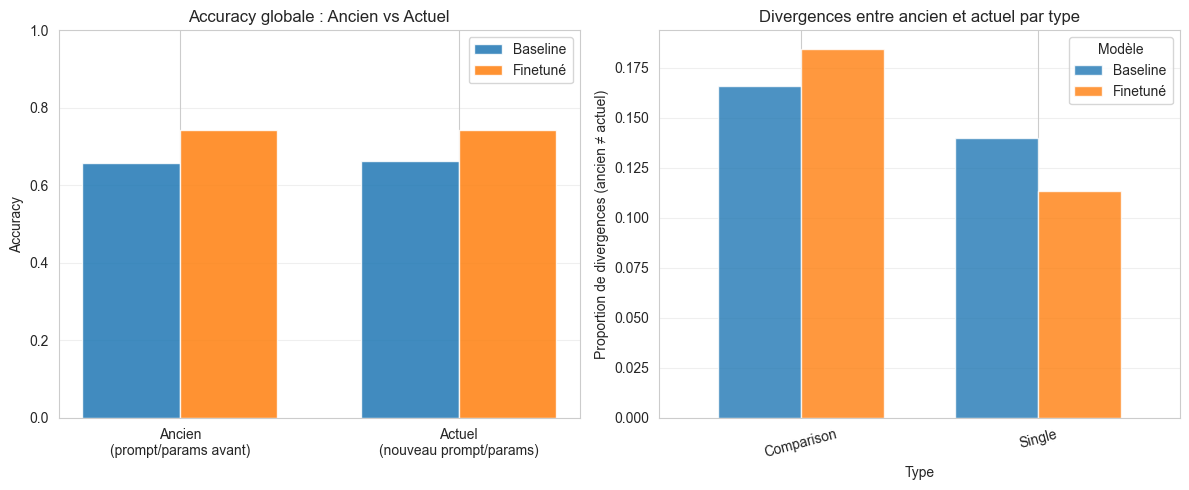

In [81]:
# Visualisation: accuracy ancien vs actuel (Baseline et Finetuné)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x = np.arange(2)
width = 0.35
labels = ['Ancien\n(prompt/params avant)', 'Actuel\n(nouveau prompt/params)']

axes[0].bar(x - width/2, [acc_avant_bl, acc_actu_bl], width, label='Baseline', color='C0', alpha=0.85)
axes[0].bar(x + width/2, [acc_avant_ft, acc_actu_ft], width, label='Finetuné', color='C1', alpha=0.85)
axes[0].set_ylabel('Accuracy')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_title('Accuracy globale : Ancien vs Actuel')
axes[0].legend()
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', alpha=0.3)

# Taux de divergence par type
div_by_type = df_compare.groupby('type').agg({'bl_divergent': 'mean', 'ft_divergent': 'mean'}).rename(columns={'bl_divergent': 'Baseline', 'ft_divergent': 'Finetuné'})
div_by_type.plot(kind='bar', ax=axes[1], width=0.7, alpha=0.8)
axes[1].set_ylabel('Proportion de divergences (ancien ≠ actuel)')
axes[1].set_xlabel('Type')
axes[1].set_title('Divergences entre ancien et actuel par type')
axes[1].legend(title='Modèle')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [82]:
# Export du tableau de comparaison pour inspection (ex. cas divergents)
compare_file = "error_analysis_compare_avant_actuel.csv"
df_compare.to_csv(compare_file, index=False)
print(f"Comparaison ancien vs actuel sauvegardée dans: {compare_file}")
print("Colonnes: index, true_label, type, section_id, statement, avant_bl_pred, avant_ft_pred, avant_bl_correct, avant_ft_correct, actu_bl_pred, actu_ft_pred, actu_bl_correct, actu_ft_correct, bl_divergent, ft_divergent")

Comparaison ancien vs actuel sauvegardée dans: error_analysis_compare_avant_actuel.csv
Colonnes: index, true_label, type, section_id, statement, avant_bl_pred, avant_ft_pred, avant_bl_correct, avant_ft_correct, actu_bl_pred, actu_ft_pred, actu_bl_correct, actu_ft_correct, bl_divergent, ft_divergent
